In [1]:
import os
import tqdm
import numpy as np
import pandas as pd
import itertools

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('.')
sys.path.append('../')
from classifier.driver import load_challenge_data
from src.data.utils import snomed_to_text


Bad key "text.kerning_factor" on line 4 in
C:\Users\riehlmn\Anaconda3\envs\physionet38\lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.3/matplotlibrc.template
or from the matplotlib source distribution


In [2]:
base_path = Path('../')
input_path = base_path.joinpath('utils/temp/')
print(input_path.resolve().absolute())

C:\Users\riehlmn\PycharmProjects\physionet\physionet2020\utils\temp


In [3]:
# Load data. This may take a while.
records, datas, headers = [], [], []
for file in tqdm.tqdm(input_path.iterdir()): # total of 86202it
    if file.name.endswith('mat'):
        data, header = load_challenge_data(str(file))
        
        records.append(file.name)
        datas.append(data)
        headers.append(header)

86202it [03:15, 440.29it/s]


In [4]:
# training1 --> A, CPSC
# training2 --> Q, Training_2
# training3 --> I, StPetersburg
# training4 --> S, PTB
# training5 --> HR, PTB-XL
# training6 --> E, Training_E

sets = ['A', 'Q', 'I', 'S', 'HR', 'E']
record = {key: [] for key in sets}
data = {key: [] for key in sets}
header = {key: [] for key in sets}

for i in range(len(records)):
    for key in sets:
        if records[i].startswith(key):
            record[key].append(records[i])
            data[key].append(datas[i])
            header[key].append(headers[i])
            


In [5]:
for i, rec in enumerate(record['I']):
    if 30 < i < 40:
        print(i + 1, rec)

32 I0032.mat
33 I0033.mat
34 I0034.mat
35 I0035.mat
36 I0037.mat
37 I0038.mat
38 I0039.mat
39 I0040.mat
40 I0041.mat


In [6]:
# summary DataFrame 
summary = pd.DataFrame(index=sets)
tranch_names = ['CPSC', 'Training_2', 'StPetersburg', 'PTB', 'PTB-XL', 'Training_E']
summary['set'] = tranch_names
n_records = [len(record[key]) for key in sets]
summary['n_records'] = n_records
summary

,set,n_records
A,CPSC,6877
Q,Training_2,3453
I,StPetersburg,74
S,PTB,516
HR,PTB-XL,21837
E,Training_E,10344


In [7]:
# check recording frequency
frequency = []
n_samples = []
amplitude_resolution = []
for key in sets:
    fq = []
    n = []
    res = []
    for h in header[key]:
        fq.append(int(h[0].split(' ')[2]))
        n.append(int(h[0].split(' ')[3]))
        res.append(int(h[1].split(' ')[2].split('/')[0]))
    frequency.append(np.unique(fq)[0]) # all records from one tranch have same frequency
    n_samples.append(n)
    amplitude_resolution.append(np.unique(res))
    
print('amplitude resolutions (mV):')
for i in range(len(sets)):
    print(sets[i], ': ', amplitude_resolution[i])

   
summary['sample frequency (Hz)'] = frequency
summary['min (s)'] = [np.min(n_samples[i] / frequency[i]) for i in range(len(n_samples))]
summary['mean (s)'] = [np.round(np.mean(n_samples[i] / frequency[i])) for i in range(len(n_samples))]
summary['max (s)'] = [np.max(n_samples[i] / frequency[i]) for i in range(len(n_samples))]
summary['avg (s)'] = [np.round(np.average(n_samples[i] / frequency[i])) for i in range(len(n_samples))]
summary

amplitude resolutions (mV):
A :  [1000]
Q :  [1000]
I :  [ 240000  248000  254000  306000  514000  515000  516000  612000  617000
  623000 1041000 1063000]
S :  [2000000]
HR :  [200]
E :  [4880]


,set,n_records,sample frequency (Hz),min (s),mean (s),max (s),avg (s)
A,CPSC,6877,500,6.0,16.0,144.000,16.0
Q,Training_2,3453,500,8.0,16.0,98.000,16.0
I,StPetersburg,74,257,1800.0,1800.0,1800.000,1800.0
S,PTB,516,1000,32.0,111.0,120.012,111.0
HR,PTB-XL,21837,500,10.0,10.0,10.000,10.0
E,Training_E,10344,500,5.0,10.0,10.000,10.0


# Data length

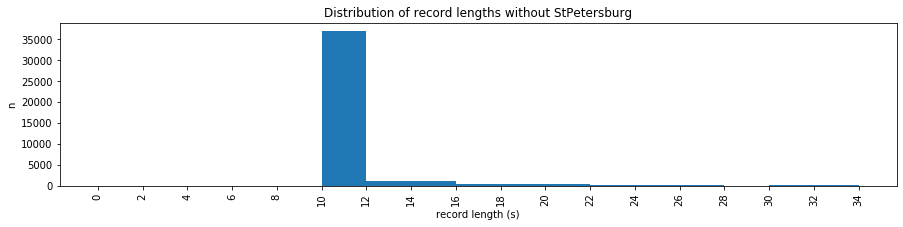

min (s):  5.0
max (s):  1800.0
most present length (s):  10


In [8]:
durations = list(itertools.chain(*[n_samples[i] / frequency[i] for i in range(len(n_samples))]))

fig = plt.figure(figsize=(15,3))

bin_width = 2
bins = np.arange(0, 35, bin_width)
hist, _, _ = plt.hist(durations, bins=bins)

plt.xticks(bins, rotation=90)
plt.xlabel('record length (s)')
plt.ylabel('n')
plt.title('Distribution of record lengths without StPetersburg')
plt.show()

durations = np.array(durations)
print('min (s): ', np.min(durations))
print('max (s): ', np.max(durations))
print('most present length (s): ', np.argmax(hist) * bin_width) # 10 s

# Class distribution

In [9]:
# Get all labels from header
label = {key: [] for key in sets}

for key in sets:
    for h in header[key]:
        for line in h:
            if line.startswith('#Dx: '):
                dx = line.split(' ')[1].split(',')
                dx[-1] = dx[-1].strip()
                label[key].append(dx)

In [10]:
n_single = [] # number of single labels
n_classes = [] # number of classes
classes = []
for key in sets:
    n = 0
    for l in label[key]:
        if len(l) == 1:
            n += 1
    n_single.append(n)
    
    classes.append(np.unique(list(itertools.chain(*label[key]))))
    n_classes.append(len(classes[-1]))
    
summary['single label (%)'] = [np.round((n_single[i] / n_records[i]) * 100) for i in range(len(n_single))]
summary['n_classes'] = n_classes

In [11]:
nlabel = []
for i in range(len(sets)):
    nlabels = { key: 0 for key in list(classes[i])}
    for key in itertools.chain(*label[sets[i]]):
        nlabels[key] += 1
        
    nlabel.append(nlabels)

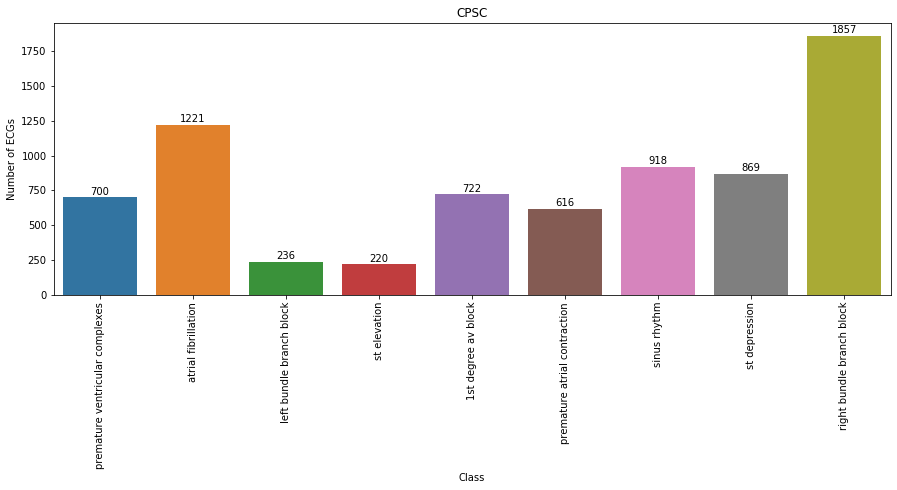

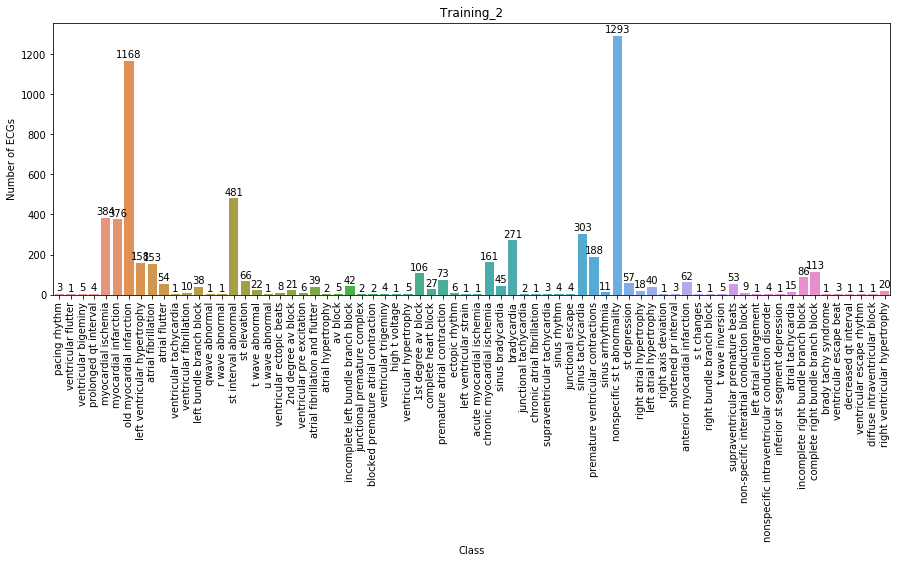

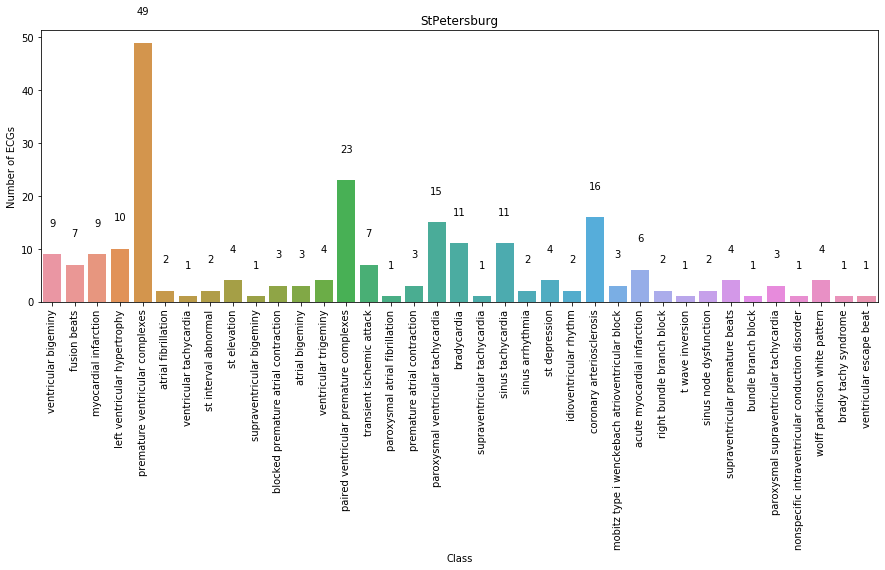

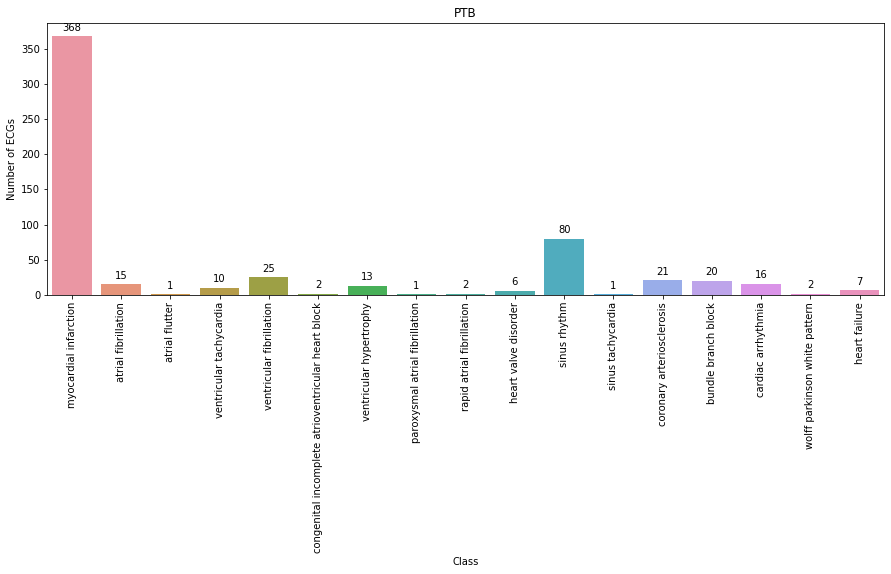

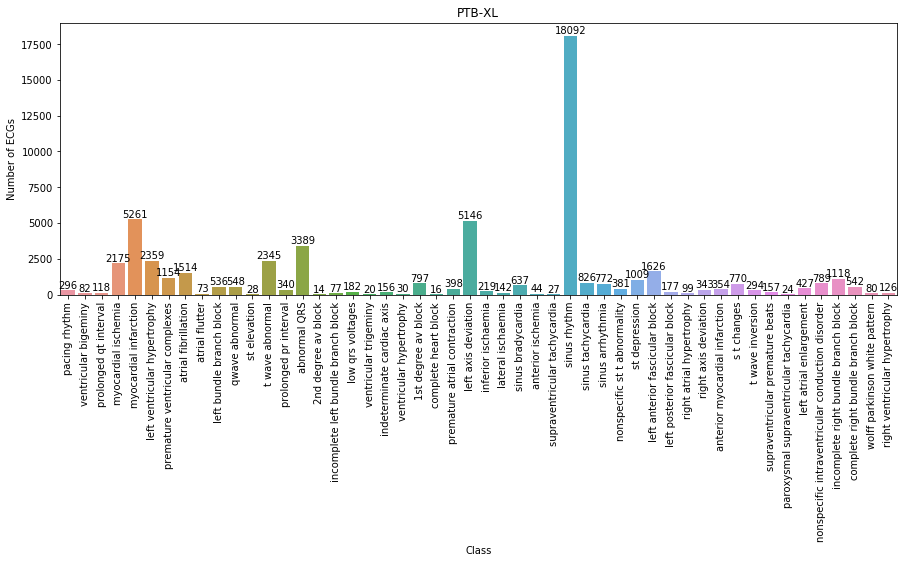

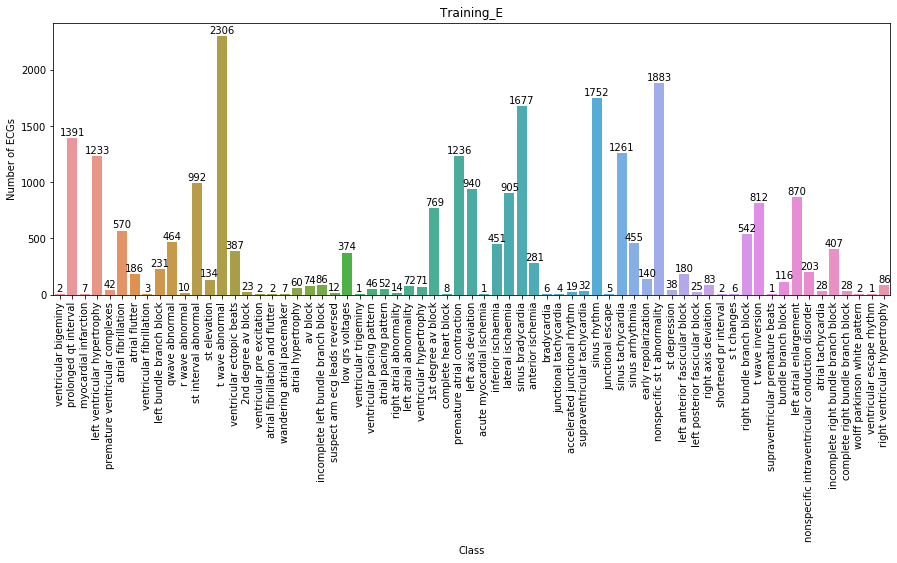

In [12]:
def plot_dist(nlabels, title):
    plt.figure(figsize=(15,5))
    text_labels = [snomed_to_text(k) for k in list(nlabels.keys())]
    ax = sns.barplot(text_labels, list(nlabels.values()))

    plt.title(title)
    plt.ylabel('Number of ECGs')
    plt.xlabel('Class')

    rects = ax.patches
    slabels = list(nlabels.values())
    for rect, label in zip(rects, slabels):
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, height + 5, label, ha='center', va='bottom')
    plt.xticks(rotation=90)
    plt.show()

for i in range(len(sets)):
    plot_dist(nlabel[i], tranch_names[i])

All:  111
n >=  10 :  77


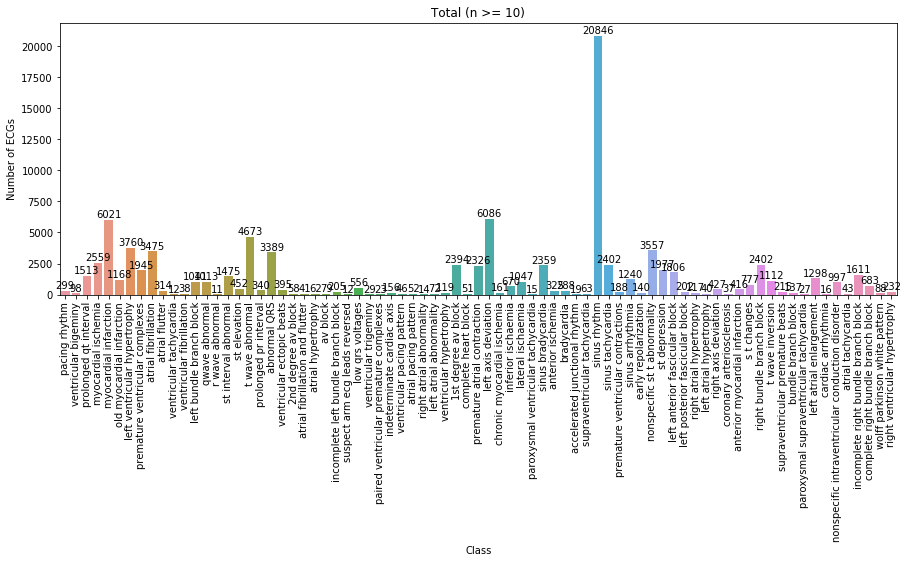

In [13]:
all_label = []
for header in headers:
    for line in header:
        if line.startswith('#Dx: '):
            dx = line.split(' ')[1].split(',')
            dx[-1] = dx[-1].strip()
            all_label.append(dx)
            
unique = np.unique(list(itertools.chain(*all_label)))
print('All: ', len(unique))
all_nlabels = { key : 0 for key in list(unique) }

for key in itertools.chain(*all_label):
    all_nlabels[key] += 1
keys = all_nlabels.keys()
delete = []
n_thresh = 10
for key in keys:
    if all_nlabels[key] < n_thresh:
        delete.append(key)
for sid in delete:
    del all_nlabels[sid]
    
print('n >= ', n_thresh, ': ', len(all_nlabels.keys()))
    
plot_dist(all_nlabels, 'Total (n >= ' + str(n_thresh) + ')')

# Summaray

In [14]:
print('single label in total (%): ', np.sum(n_single) / np.sum(n_records) * 100)
summary

single label in total (%):  45.16368529732489


,set,n_records,sample frequency (Hz),min (s),mean (s),max (s),avg (s),single label (%),n_classes
A,CPSC,6877,500,6.0,16.0,144.000,16.0,93.0,9
Q,Training_2,3453,500,8.0,16.0,98.000,16.0,49.0,72
I,StPetersburg,74,257,1800.0,1800.0,1800.000,1800.0,11.0,37
S,PTB,516,1000,32.0,111.0,120.012,111.0,88.0,17
HR,PTB-XL,21837,500,10.0,10.0,10.000,10.0,32.0,50
E,Training_E,10344,500,5.0,10.0,10.000,10.0,38.0,67


In [17]:
examples = [2, 7, 8, 76, 77]
examples = range(214, 219)
for e in examples:
    i = e - 1
    print(record['HR'][i])
    print([snomed_to_text(l) for l in label['HR'][i]])
    print()

HR00214.mat
['sinus rhythm']

HR00215.mat
['sinus rhythm']

HR00216.mat
['sinus rhythm']

HR00217.mat
['t wave abnormal', 'sinus rhythm']

HR00218.mat
['1st degree av block', 'sinus rhythm']

